In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "1" 
print(os.cpu_count())

144


In [2]:
from tqdm import tqdm
import numpy as np
from copy import deepcopy
import random as rand
import scipy.linalg
from scipy.sparse import csc_matrix
from qulacs import QuantumState,QuantumCircuit, Observable, PauliOperator,ParametricQuantumCircuit,DensityMatrix, GeneralQuantumOperator
from qulacs.gate import H,X,Y,Z,RX,RY,RZ,CNOT,CZ,TOFFOLI,SWAP,merge,DenseMatrix,add, Probabilistic, P0, P1,to_matrix_gate,PauliRotation,Pauli, RandomUnitary, SparseMatrix
from qulacs.state import inner_product, partial_trace, tensor_product

# Simultaneous diagonalization with Stim

Given a set of Pauli strings that commute with each other, the following code can find a Clifford circuit to simultaneously diagonalize these Pauli strings.

Consider Pauli strings $O_1^{(0)},O_2^{(0)},\ldots,$ with $[O_i^{(0)},O_j^{(0)}]=0$.
We first find an $n$-qubit unitariy transformation $U^{(1)}$ such that $O_1^{(1)}\equiv U^{(1)} O_1^{(0)} U^{(1)\dagger} = Z_n$.
Then, $O_j^{(1)}\equiv U^{(1)} O_j^{(0)} U^{(1)\dagger}$ satisfies  $O_j^{(1)}=A_{1:n-1} \otimes B_{n}$, where $A_{1:n-1}$ is an $(n-1)$-qubits Pauli string, and $B_n=I,Z$ (we have ignored the index $j$).
This is because $[O_1^{(1)}, O_j^{(1)}]=0$.

Subsequently, we find an $(n-1)$-qubit unitariy transformation $U^{(2)}$ on all qubits except the $n$-th such that $O_2^{(2)}\equiv U^{(2)} O_2^{(1)} U^{(2)\dagger} = Z_{n-1}$ or $Z_{n-1}Z_n$.
Then, $O_j^{(2)}\equiv U^{(2)} O_j^{(1)} U^{(2)\dagger}$ satisfies  $O_j^{(2)}=A_{1:n-2} \otimes B_{n-1:n}$, where $A_{1:n-2}$ is an $(n-2)$-qubits Pauli string, and $B_{n-1:n}=II,IZ,ZI,ZZ$.
This is because $[O_2^{(2)}, O_j^{(2)}]=0$.

Repeating this procedure, we can find a unitary transformation $U=\cdots U^{(2)} U^{(1)}$ that simultaneously diagonalizes all Pauli strings.

In [3]:
import stim
cnot = stim.Tableau.from_named_gate("CNOT") #CNOT
cz = stim.Tableau.from_named_gate("CZ") #CNOT
swap = stim.Tableau.from_named_gate("SWAP") #SWAP
H = stim.Tableau.from_named_gate("H") #H
S = stim.Tableau.from_named_gate("S") #S
X = stim.Tableau.from_named_gate("X") #X
Sd = S**-1 #S^dag

In [4]:
"""
For an n-qubit Pauli string P = P_{1}...P_{m-1}P_{m}P_{m+1}...P_{n}、find an Clifford operator U such that U P U^\dag = I_{1}...I_{m-1}Z_{m}P_{m+1}...P_{n}.
"""
def pauli_to_Z(pauli, nqubits, m):
    
    t = stim.Tableau(nqubits)
    
    # Find the first non-identity Pauli operator by counting from the m-th qubit downwards (i.e., m-th, (m-1)-th, ...), and then swap it with the m-th qubit.
    st = m-1
    for _ in range(m):
        if pauli[st] != 0:
            break
        else:
            st -= 1
            
    if st == -1:
        return False # P_{1}, ..., P_{m-1}, P_{m} = I
    elif st != m-1:
        t.append(swap,[st, m-1]) # swap
        
    pauli2 = t(pauli)
  

    # transform each Pauli component to Z
    for j in range(m):
        if pauli2[j] == 1:
            t.append(H,[j])
        elif pauli2[j] == 2:
            t.append(Sd,[j])
            t.append(H,[j])
            
    t.append(H,[m-1])
    
    # propagate Z to each qubit with CZ gates
    for j in range(m-1):
        if pauli2[j] != 0:
            t.append(cz, [j,m-1])
            
    t.append(H,[m-1])
            
    return t

In [5]:
"""
Find a Clifford transformation that converts all Pauli strings in pauli_list (for an n-qubit system) into the Z-basis.
"""
def diag(pauli_list, nqubits):
    
    circ = stim.Tableau(nqubits)
    pauli_temp = pauli_list
    j = 0
    count = 0
    while count < nqubits and j < len(pauli_list):
        t = pauli_to_Z(pauli_temp[j], nqubits, nqubits-count)
        #print(t)
        if t != False:
            circ = t*circ
            pauli_temp = [circ(p) for p in pauli_list]
            j += 1
            count += 1
        else:
            j += 1
            
    return circ

In [6]:
def to_check_matrix(pauli_str):
    """Convert a Pauli string (e.g., "X 0 Z 1 X 2 X 3 I 4 I 5 I 6 I 7 I 8") to its check matrix representation as a row vector."""
    str = ''.join([char for char in pauli_str if not char.isdigit() and not char.isspace()])
    conversion_Xdict = {
        'I': 0,
        'X': 1,
        'Y': 1,
        'Z': 0
    }

    conversion_Zdict = {
        'I': 0,
        'X': 0,
        'Y': 1,
        'Z': 1,
    }

    #
    vector1 = []
    vector2 = []
    for char in str:
        vector1.append(conversion_Xdict[char])
        vector2.append(conversion_Zdict[char])

    return np.concatenate((vector1, vector2))

def to_pauli(check_mat):
    # 
    conversion = {
        0:'I',
        1:'X',
        2:'Z', 
        3:'Y' 
    }
    nqubits = len(check_mat)//2
    pauli = ""
    for i in range(nqubits):
        k = check_mat[i] + 2*check_mat[nqubits+i]
        pauli += conversion[k]

    return pauli


def check_comm(check_mat1, check_mat2):
    
    ### Lambda matrix
    # Create the n x n identity matrix
    n = len(check_mat1)//2
    I_n = np.eye(n)

    # Create the 2n x 2n block matrix
    top_row = np.hstack((np.zeros((n, n)), I_n))
    bottom_row = np.hstack((I_n, np.zeros((n, n))))

    lam = np.vstack((top_row, bottom_row))
    
    ### 
    a = int( check_mat1 @ lam @ check_mat2.T )
    return a%2

In [7]:
# Construct SLPA generators from sets of logical operators and stabilizers.
def SLP(logic, stab):
    glist = []
    for l in logic:
        block = []
        for s in stab:
            block.append( pauli_prod(l,s) )
        glist.append( block )
            
    return glist
            
def pauli_prod(l, s):
    check_mat1 = to_check_matrix(l)
    check_mat2 = to_check_matrix(s)
    ch = (check_mat1 + check_mat2)%2 
    p = to_pauli(ch)
    return p

def pauli_prod_sign(l, s):
    lstr = from_string_to_sentence(l)
    sstr = from_string_to_sentence(s)
    prod = PauliOperator(lstr, 1.0)*PauliOperator(sstr, 1.0)
    
    pauli = prod.get_pauli_string()
    coef = prod.get_coef()
    return pauli, coef

In [8]:
# string: "XYII"
# sentence: "X 0 Y 1"
# TP: (target,pauli)=([0,1],[1,2])
def from_string_to_sentence(string):
    sentence = ""
    for j,s in enumerate(string):
        if s=="X":
            sentence += f"X {j} "
        elif s=="Y":
            sentence += f"Y {j} "
        elif s=="Z":
            sentence += f"Z {j} "
            
    return sentence


def from_string_to_TP(string):
    target = []
    pauli = []
    for j,s in enumerate(string):
        if s=="X":
            target.append(j)
            pauli.append(1)
        elif s=="Y":
            target.append(j)
            pauli.append(2)
        elif s=="Z":
            target.append(j)
            pauli.append(3)
            
    return target, pauli

### functions

In [9]:
# efficient sampling
def sampling_binomial(obs,qstate,num_samp):
    ex = np.real( obs.get_expectation_value(qstate) )
    p = (ex + 1.0)/2.0
    p_sample = np.random.binomial(num_samp, p, 1)[0]/num_samp
    result = 2*p_sample - 1.0
    
    return result

# SLPA

Assume that stabilizers commute with the measurement observable

In [10]:
class SLPA:
    def __init__(self, nqubits, obs_str, stab, logic):
        
        """ Basics """
        # s
        self.nqubits = nqubits
        self.obs = PauliOperator(from_string_to_sentence(obs_str), 1.0)
        self.obs_str = obs_str
        
        # generators
        self.stab = stab
        self.logic = logic
        self.glist = SLP(self.logic, self.stab)
        
        # target and pauli indices
        self.target_list = []
        self.pauli_list = []
        for block in self.glist:
            target = []
            pauli = []
            for g in block:
                t,p = from_string_to_TP(g)
                target.append(t)
                pauli.append(p)
            self.target_list.append(target)
            self.pauli_list.append(pauli)
            
        # numbers
        self.num_stabs = len(self.stab)
        self.num_blocks = len(self.logic)
        self.num_params = sum(len(row) for row in self.glist)
        self.params_block = np.zeros((self.num_blocks,self.num_stabs))
                

        """ Commutation relations """
        # Commutation relation between the a-th block and observable O. 0 if commutes, 1 if anti-commutes.
        self.g_coef = []
        check_mat0 = to_check_matrix(self.obs_str)
        for a in range(len(logic)):
            check_mat1 = to_check_matrix(self.logic[a])
            g = check_comm(check_mat0, check_mat1)
            self.g_coef.append(g)


        # Commutation relation between the a-th and b-th blocks.
        self.block_comm = []
        for a in range(self.num_blocks):
            block = []
            for b in range(self.num_blocks):
                check_mat1 = to_check_matrix(self.logic[a])
                check_mat2 = to_check_matrix(self.logic[b])
                g = check_comm(check_mat1, check_mat2)
                block.append(g)
            self.block_comm.append(block)
            
        """ Diagonalize measurement observables """
        # Measurement observables O_j^a = i^(g_j^a) * G_j^a * O
        self.obs_list = []
        for a in range(self.num_blocks):
            temp = []
            for b in range(self.num_stabs):
                g = self.glist[a][b]
                if self.g_coef[a]==0:
                    temp.append( stim.PauliString(g)*stim.PauliString(self.obs_str) )
                else:
                    temp.append( stim.PauliString("+i")*stim.PauliString(g)*stim.PauliString(self.obs_str) )
            self.obs_list.append(temp)    
            
            
        # Find a Clifford transformation to diagonalize measurement operators for each block.
        self.diag_gate = []
        self.obs_trans_list = []
        for obs in self.obs_list:
            u_stim = diag(obs, self.nqubits)
            u = u_stim.to_unitary_matrix(endian='little')
            u_csc = csc_matrix(u)
            gate = SparseMatrix([i for i in range(self.nqubits)], u_csc)
            self.diag_gate.append(gate)

            # How each measurement operator is transformed after diagonalization
            temp = []
            for o in obs:
                o_trans = u_stim(o)
                temp.append(o_trans)
            self.obs_trans_list.append(temp)


        # Mark the positions of Z operators in the diagonalized measurement observable tilde{O}_j^a = G_j^a*O \otimes Z
        self.obs_marker = []
        for block in self.obs_trans_list:
            temp = []
            for obs in block:
                x = []
                for i in range(self.nqubits):
                    if obs[i]==3: # Pauli Z
                        x.append(1)
                    else:
                        x.append(0)
                x.append(1) # Add a marker for the auxiliary qubit, if any
                temp.append(x)
            self.obs_marker.append(temp)
            
        # Extract only the coefficients of the observables
        self.obs_coef = [[2.0*obs.sign/2.0 for obs in obs_trans] for obs_trans in self.obs_trans_list] # Divide by 2 because qulacs defines as exp(i theta P/2)
        
        # Qulacs format of measurement operators
        self.obs_qulacs = []
        for a in range(num_blocks):
            l = []
            for b in range(num_stabs):
                x = self.obs_marker[a][b]
                string = ""
                for j in range(self.nqubits+1):
                    if x[j]==0:
                        string += f"I {j} "
                    else:
                        string += f"Z {j} "
                l.append( PauliOperator(string, self.obs_coef[a][b]) )
            self.obs_qulacs.append( l )
        
        
        
        """ Quantum circuits """
        # Quantum circuit for expectation value
        self.circ0 = ParametricQuantumCircuit(self.nqubits)
        for a in range(self.num_blocks):
            for (t,p) in zip(self.target_list[a], self.pauli_list[a]):
                self.circ0.add_parametric_multi_Pauli_rotation_gate(t, p, 0.0)
        
        # Quantum circuit for gradient 
        """
        control-exp(iaP)=exp(iaP/2) exp(-ia(ZP)/2)
        anticontrol-exp(iaP)=exp(iaP/2) exp(ia(ZP)/2)
        """
        self.gcirc_list = []
        for b in range(self.num_blocks):
            gcirc = ParametricQuantumCircuit(nqubits+1) # First, define the quantum circuit.
            gcirc.add_H_gate(nqubits)

            ###########################################################################
            # Act normally up to the b-th block (including b-th block!)
            ###########################################################################
            for a in range(b+1):
                for (t,p) in zip(self.target_list[a], self.pauli_list[a]):
                    gcirc.add_parametric_multi_Pauli_rotation_gate(t, p, 0.0)


            ###########################################################################
            ### control-W'
            ###########################################################################
            for a in range(b+1,self.num_blocks):
                for (t,p) in zip(self.target_list[a], self.pauli_list[a]):
                    gcirc.add_parametric_multi_Pauli_rotation_gate(t+[nqubits], p+[3], 0.0)
                    gcirc.add_parametric_multi_Pauli_rotation_gate(t, p, 0.0)


            # Coefficient (determined by the commutation relation between generator and observable)
            if self.g_coef[b]==0:
                gate = PauliRotation([0],[0],-np.pi) 
                gate_mat = to_matrix_gate(gate)
                gate_mat.add_control_qubit(nqubits, 1)
                gcirc.add_gate(gate_mat)
            else:
                gate = PauliRotation([0],[0],-2*np.pi) 
                gate_mat = to_matrix_gate(gate)
                gate_mat.add_control_qubit(nqubits, 1)
                gcirc.add_gate(gate_mat)


            ###########################################################################
            ### control-tilde{W}
            ###########################################################################
            for a in range(b+1,self.num_blocks):
                coef = (-1)**self.block_comm[a][b]
                for (t,p) in zip(self.target_list[a], self.pauli_list[a]):
                    gcirc.add_parametric_multi_Pauli_rotation_gate(t+[nqubits], p+[3], 0.0)
                    gcirc.add_parametric_multi_Pauli_rotation_gate(t, p, 0.0)            

            gcirc.add_H_gate(nqubits)
            gcirc.add_gate( self.diag_gate[b] ) # Basis transformation
            
            self.gcirc_list.append(gcirc)

    
    """ Parameter update """ 
    def set_params(self, params_block):
        self.params_block = params_block
    
     
    # Update parameters of the circuit
    def update_params_circ0(self):
        params = [p for block in self.params_block for p in block]
        for i in range(self.num_params):
            self.circ0.set_parameter(i, params[i])
        
    
    # Update parameters of gradient calculation circuits
    def update_params_gcirc(self, b):

        x = 0 # Parameter count
        ###########################################################################
        # Act normally up to the b-th block (including b-th block!)
        ###########################################################################
        for a in range(b+1):
            for angle in self.params_block[a]:
                self.gcirc_list[b].set_parameter(x, angle)
                x += 1

        ###########################################################################
        ### control-W'
        ###########################################################################
        for a in range(b+1,self.num_blocks):
            for angle in self.params_block[a]:
                self.gcirc_list[b].set_parameter(x, -angle/2.0)
                x += 1
                self.gcirc_list[b].set_parameter(x, angle/2.0)
                x += 1

        ###########################################################################
        ### control-tilde{W}
        ###########################################################################
        for a in range(b+1,self.num_blocks):
            coef = (-1)**self.block_comm[a][b]
            for angle in self.params_block[a]:
                self.gcirc_list[b].set_parameter(x, coef*angle/2.0)
                x += 1
                self.gcirc_list[b].set_parameter(x, coef*angle/2.0)
                x += 1
            
    
    """ Expectation value and gradient calculations """
    def cal_expval(self, data, num_samp):
        qstate = QuantumState(nqubits)
        qstate.load(data)
        self.update_params_circ0()
        self.circ0.update_quantum_state(qstate)
        r = sampling_binomial(self.obs, qstate, num_samp)  
        return np.real(r)
    
    def cal_expval_exact(self, data):
        qstate = QuantumState(nqubits)
        qstate.load(data)
        self.update_params_circ0()
        self.circ0.update_quantum_state(qstate)
        r = self.obs.get_expectation_value(qstate) 
        return np.real(r)
        
    
    def cal_grad(self, data, num_samp):

        grad = np.zeros_like(self.params_block)
        for b in range(self.num_blocks): 
            qstate1 = QuantumState(self.nqubits)
            qstate1.load(data)
            qstate2 = QuantumState(1)
            qstate = tensor_product(qstate2, qstate1) # Order is important!

            self.update_params_gcirc(b)
            self.gcirc_list[b].update_quantum_state(qstate)
            samples = qstate.sampling(num_samp)
            bit_strings = [format(sample, f'0{self.nqubits+1}b') for sample in samples] # Note: bit order is reversed!

            for i,marker in enumerate(self.obs_marker[b]):
                #print(marker)
                for string in bit_strings:                

                    #== Calculate output
                    ex = 0
                    for j in range(self.nqubits+1):
                        ex += int(string[self.nqubits-j])*marker[j] 
                    outcome = (-1)**ex
                    #==

                    grad[b, i] += np.real(self.obs_coef[b][i] * outcome)/num_samp
            
        return grad
    
    """ To add exact gradient calculation """
    def cal_grad_exact(self, data):

        grad = np.zeros_like(self.params_block)
        for b in range(self.num_blocks): 
            qstate1 = QuantumState(self.nqubits)
            qstate1.load(data)
            qstate2 = QuantumState(1)
            qstate = tensor_product(qstate2, qstate1) # Order is important!

            self.update_params_gcirc(b)
            self.gcirc_list[b].update_quantum_state(qstate)
            
            for i in range(num_stabs):
                obs = self.obs_qulacs[b][i]
                grad[b, i] = np.real( obs.get_expectation_value(qstate) )
            
        return grad

# Example

VQE for Hamiltonian H=XXII

In [11]:
nqubits = 4
obs = "X 0 X 1 I 2 I 3"
obs_str = "XXII"

stab = [
"IIII",
"XXXX",
"ZZZZ",
"YYYY"
]

logic = [
"XXII", "IIYY", 
"IZZI", "XIIX", 
"YYII", "IIZZ", 
"IXXI", "YIIY", 
"ZZII", "IIXX", 
"IYYI", "ZIIZ",
"XXII", "IIYY", 
"IZZI", "XIIX", 
"YYII", "IIZZ", 
"IXXI", "YIIY", 
"ZZII", "IIXX", 
"IYYI", "ZIIZ"
]

num_stabs = 4
num_blocks = 24

slpa = SLPA(nqubits, obs_str, stab, logic)

0.3420000000000001 0.30411538890940504


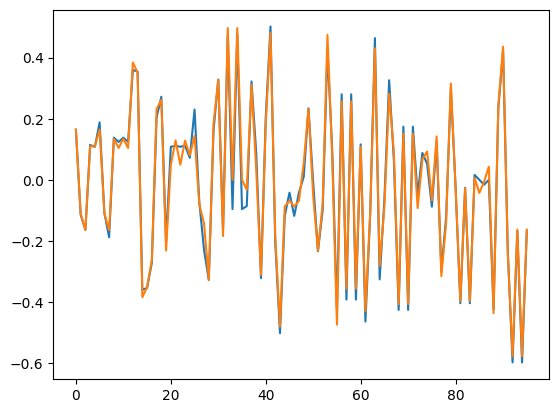

In [12]:
# test
import matplotlib.pyplot as plt
qstate = QuantumState(4)
data = qstate.get_vector()
params_block = 2*np.pi*np.random.rand(num_blocks, num_stabs)

slpa.set_params(params_block)
a=slpa.cal_expval(data,1000)
b=slpa.cal_expval_exact(data)
c=slpa.cal_grad(data,1000)
d=slpa.cal_grad_exact(data)

print(a,b)
c = [y for x in c for y in x]
d = [y for x in d for y in x]
plt.plot(c)
plt.plot(d)

In [13]:
num_epochs = 150
qstate = QuantumState(4)
data = qstate.get_vector()
params_block = 2*np.pi*np.random.rand(num_blocks, num_stabs)
params_block = np.zeros((num_blocks, num_stabs))

cost = []
for _ in tqdm(range(num_epochs)):
    slpa.set_params(params_block)
    x = slpa.cal_expval_exact(data)
    cost.append(x)
    
    grad=slpa.cal_grad(data,1000)
    params_block -= 0.01*grad

100%|██████████| 150/150 [00:30<00:00,  4.90it/s]


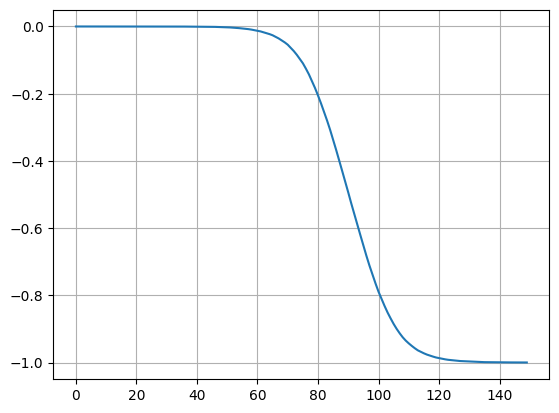

In [14]:
plt.plot(cost)
plt.grid()